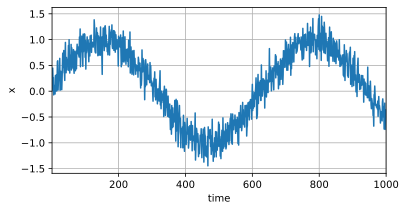

In [2]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt
T=1000
time=torch.arange(1,1+T,dtype=torch.float32)
x=torch.sin(0.01*time)+torch.normal(0,0.2,(T,))

d2l.plot(time,[x],'time','x',xlim=[1,1000],figsize=(6,3))


使用plt也可以,只是代码多了一点  

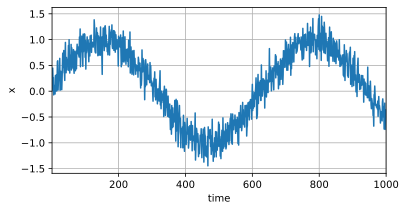

In [3]:
plt.figure(figsize=(6,3))
plt.plot(time.numpy(),x.numpy())
plt.xlabel('time')
plt.ylabel('x')
plt.xlim(1,1000)
plt.grid(True)
plt.show()

In [4]:
# 每个数据由他前tau个数据训练和预测
# 前tau个数据不满足上一行的条件,没有前面的tau个数据,因此不用于训练
tau=4
#初始化fea 每个行一个样例
features=torch.zeros((T-tau,tau))
for i in range(tau):
    features[:,i]=x[i:T-tau+i]
labels=x[tau:].reshape((-1,1))

# 1000 data in total,600 for training
# batch_size :一次训练看几个数据 epoch:把全部数据看多少遍
batch_size,n_train=16,600
train_iter=d2l.load_array((features[:n_train],labels[:n_train]),
                        batch_size,is_train=True)



In [5]:
def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net=nn.Sequential(nn.Linear(4,10),nn.ReLU(),nn.Linear(10,1))
    net.apply(init_weights)
    return net

loss=nn.MSELoss(reduction='none')


In [11]:
def train(net,train_iter,loss,epochs,lr):
    trainer=torch.optim.Adam(net.parameters(),lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()   
            l=loss(net(X),y)
            l.sum().backward() # 算梯度
            trainer.step()  #更新参数
        print(f'epoch {epoch+1},'
            f'loss: {d2l.evaluate_loss(net,train_iter,loss):f}')#整体的loss而不是一个batch的 不稳定

net=get_net()
train(net,train_iter,loss,5,0.1)

    

epoch 1,loss: 0.053806
epoch 2,loss: 0.055536
epoch 3,loss: 0.052330
epoch 4,loss: 0.053580
epoch 5,loss: 0.049450


In [14]:
net.eval()
with torch.no_grad():
    for X,y in train_iter:
        pred=net(X)
        for i in range(min(10,X.shape[0])):
            print(f'预测: {pred[i].item():.3f}  真实: {y[i].item():.3f}')
        break

预测: -0.974  真实: -1.307
预测: 0.527  真实: 0.412
预测: 0.885  真实: 0.763
预测: 1.118  真实: 0.688
预测: 0.981  真实: 1.028
预测: -0.659  真实: -0.633
预测: 0.769  真实: 1.067
预测: 0.713  真实: 0.535
预测: -0.578  真实: -0.305
预测: 0.682  真实: 0.910


还不错喵

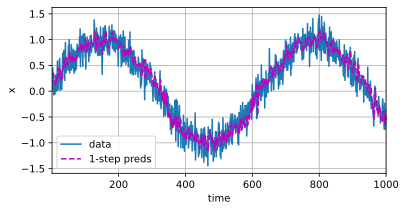

In [16]:
onestep_preds=net(features)
#画两条线 第一个参数是[line1的x的list,line2的x的list] 第二个参数y同理,一一对应
d2l.plot([time,time[tau:]],
        [x.detach().numpy(),onestep_preds.detach().numpy()],
        'time','x',legend=['data','1-step preds'],xlim=[1,1000],
        figsize=(6,3)
        )
# legend — 给每条线起个名字，图上会显示标签方便区分

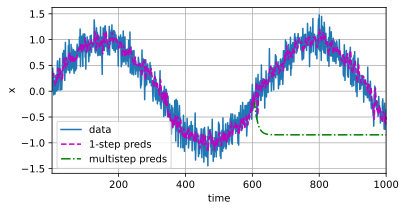

In [18]:
multistep_preds=torch.zeros(T)
multistep_preds[:n_train+tau]=x[:n_train+tau]
for i in range(n_train+tau,T):
    multistep_preds[i]=net(multistep_preds[i-tau:i].reshape((1,-1)))

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

迅速就嘎了,给到拉完了,多步预测会积累错误

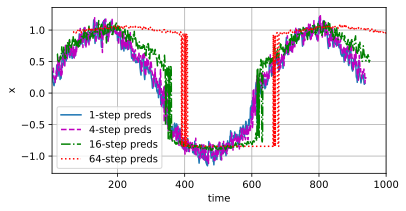

In [19]:
max_steps = 64

features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是来自x的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))